# Growth-Geometry Split notebook for $\Omega_m$

This notebook works with the `cloelib` branch `346-omegam-split-ODE-growth-rescale-power-spectrum` . The plots show the validation with the CosmoSIS implementation but work only if one has the pickle outputs. That is why they are commented out.

In [ ]:
import numpy as np
# import pickle
import matplotlib.pyplot as plt
from cloelib.cosmology.class_cosmology import CLASSBackground, CLASSLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import (
    HMemuLinearPerturbations,
    HMemuNonLinearPerturbations,
)
from cloelib.cosmology.derived_cosmology import growth_function_ODE
from cloelib.cosmology.split_cosmology import (
    SplitLinearPerturbations,
    SplitNonLinearPerturbations,
)
# import jupyter_black

# jupyter_black.load()

2026-07-17 14:33:35.591236: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784291615.792218    3788 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784291615.872529    3788 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1784291616.350158    3788 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784291616.350196    3788 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1784291616.350198    3788 computation_placer.cc:177] computation placer alr

/home/fkeil/miniforge3/envs/cloe-org/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...


2026-07-17 14:33:51.279415: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [2]:
# Cosmology parameters

H0 = 69.0
h = H0 / 100.0
Omega_b0 = 0.048
Omega_m = 0.3
Omega_cdm0 = Omega_m - Omega_b0
Omega_k0 = 0.0
w = -1.0
wa = 0.0
ns = 0.97
As = 2.19e-9
gamma_MG = 0.0
mnu = 0.0773  # Cannot be zero for HMCodeEmu
N_ur = 2.0308
N_mnu = 1

z = np.linspace(0, 3, 100)
# Compute the background with CLASS
class_instance_03 = CLASSBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_cdm0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    mnu=mnu,
    N_ur=N_ur,
    N_mnu=N_mnu,
)

## Differential Equation for the Growth G(z)

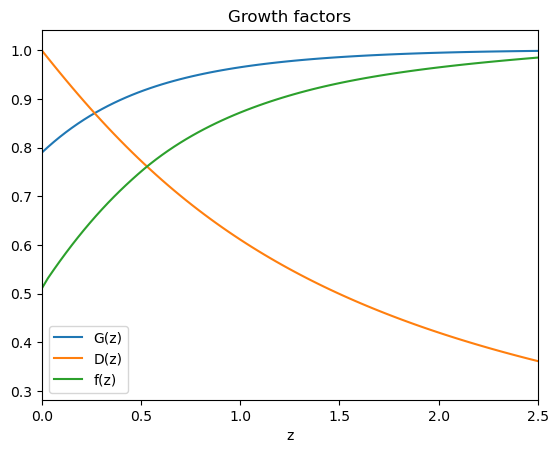

In [ ]:
# Test the differential equation for the growth G(z)
g_z_3 = growth_function_ODE(class_instance_03, z)
plt.plot(z, g_z_3, label="G(z)")
plt.xlabel("z")
plt.title("Growth factors")

# Test D(z) from the split class
ks = np.logspace(np.log10(1e-5), np.log10(1e0), 200)

class_linear = CLASSLinearPerturbations(background=class_instance_03, redshifts=z)
split_linear_03_03 = SplitLinearPerturbations(
    background=class_instance_03,
    omega_m_growth=0.300,
    redshifts=z,
    lin_perturbations=class_linear,
)

d_z_growth = split_linear_03_03.growth_factor(z, ks)

plt.plot(z, d_z_growth[:, 0], label="D(z)")

f_z_growth = split_linear_03_03.growth_rate()

plt.plot(z, f_z_growth, label="f(z)")
plt.xlabel("z")
plt.legend()
plt.xlim(0, 2.5)
plt.show()

## Rescaled Matter Power Spectrum
Plots show the CosmoSIS Validation where we implemented the growth-geometry split. This only works with the pickle files from CosmoSIS.

In [5]:
ks = np.logspace(np.log10(1e-5), np.log10(1e0), 200)

# Compute the split MPS for 5 combinations of values for Omega_m^geo and
# Omega_m^growth

# Omega_m^geo = 0.3, Omega_m^growth = 0.3

class_linear = CLASSLinearPerturbations(background=class_instance_03, redshifts=z)
split_linear_03_03 = SplitLinearPerturbations(
    background=class_instance_03,
    omega_m_growth=0.3,
    redshifts=z,
    lin_perturbations=class_linear,
)

hmemu_linear_03 = HMemuLinearPerturbations(background=class_instance_03, redshifts=z)
hmemu_nonlinear_03 = HMemuNonLinearPerturbations(
    background=class_instance_03, redshifts=z, linearperturbations=hmemu_linear_03
)
split_nonlinear_03_03 = SplitNonLinearPerturbations(
    background=class_instance_03,
    redshifts=z,
    lin_perturbations_split=split_linear_03_03,
    lin_perturbations_growth=hmemu_linear_03,
    nl_perturbations_growth=hmemu_nonlinear_03,
)
nonlinear_pk_03_03 = split_nonlinear_03_03.matter_power_spectrum(z, ks)

# Omega_m^geo = 0.3, Omega_m^growth = 0.25

split_linear_03_025 = SplitLinearPerturbations(
    background=class_instance_03,
    omega_m_growth=0.25,
    redshifts=z,
    lin_perturbations=class_linear,
)

Omega_m = 0.25
class_instance_025 = CLASSBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_m - Omega_b0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    mnu=mnu,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    N_ur=N_ur,
    N_mnu=N_mnu,
)

hmemu_linear_025 = HMemuLinearPerturbations(background=class_instance_025, redshifts=z)
hmemu_nonlinear_025 = HMemuNonLinearPerturbations(
    background=class_instance_025, redshifts=z, linearperturbations=hmemu_linear_025
)

split_nonlinear_03_025 = SplitNonLinearPerturbations(
    background=class_instance_03,
    redshifts=z,
    lin_perturbations_split=split_linear_03_025,
    lin_perturbations_growth=hmemu_linear_025,
    nl_perturbations_growth=hmemu_nonlinear_025,
)
nonlinear_pk_03_025 = split_nonlinear_03_025.matter_power_spectrum(z, ks)

# # Omega_m^geo = 0.3, Omega_m^growth = 0.35

split_linear_03_035 = SplitLinearPerturbations(
    background=class_instance_03,
    omega_m_growth=0.35,
    redshifts=z,
    lin_perturbations=class_linear,
)

Omega_m = 0.35
class_instance_035 = CLASSBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_m - Omega_b0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    mnu=mnu,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    N_ur=N_ur,
    N_mnu=N_mnu,
)
hmemu_linear_035 = HMemuLinearPerturbations(background=class_instance_035, redshifts=z)
hmemu_nonlinear_035 = HMemuNonLinearPerturbations(
    background=class_instance_035, redshifts=z, linearperturbations=hmemu_linear_035
)
split_nonlinear_03_035 = SplitNonLinearPerturbations(
    background=class_instance_03,
    redshifts=z,
    lin_perturbations_split=split_linear_03_035,
    lin_perturbations_growth=hmemu_linear_035,
    nl_perturbations_growth=hmemu_nonlinear_035,
)
nonlinear_pk_03_035 = split_nonlinear_03_035.matter_power_spectrum(z, ks)

# Omega_m^geo = 0.25, Omega_m^growth = 0.3

class_linear = CLASSLinearPerturbations(background=class_instance_025, redshifts=z)
split_linear_025_03 = SplitLinearPerturbations(
    background=class_instance_025,
    omega_m_growth=0.3,
    redshifts=z,
    lin_perturbations=class_linear,
)

split_nonlinear_025_03 = SplitNonLinearPerturbations(
    background=class_instance_025,
    redshifts=z,
    lin_perturbations_split=split_linear_025_03,
    lin_perturbations_growth=hmemu_linear_03,
    nl_perturbations_growth=hmemu_nonlinear_03,
)
nonlinear_pk_025_03 = split_nonlinear_025_03.matter_power_spectrum(z, ks)

# # Omega_m^geo = 0.35, Omega_m^growth = 0.3

class_linear = CLASSLinearPerturbations(background=class_instance_035, redshifts=z)
split_linear_035_03 = SplitLinearPerturbations(
    background=class_instance_035,
    omega_m_growth=0.3,
    redshifts=z,
    lin_perturbations=class_linear,
)

split_nonlinear_035_03 = SplitNonLinearPerturbations(
    background=class_instance_035,
    redshifts=z,
    lin_perturbations_split=split_linear_035_03,
    lin_perturbations_growth=hmemu_linear_03,
    nl_perturbations_growth=hmemu_nonlinear_03,
)
nonlinear_pk_035_03 = split_nonlinear_035_03.matter_power_spectrum(z, ks)

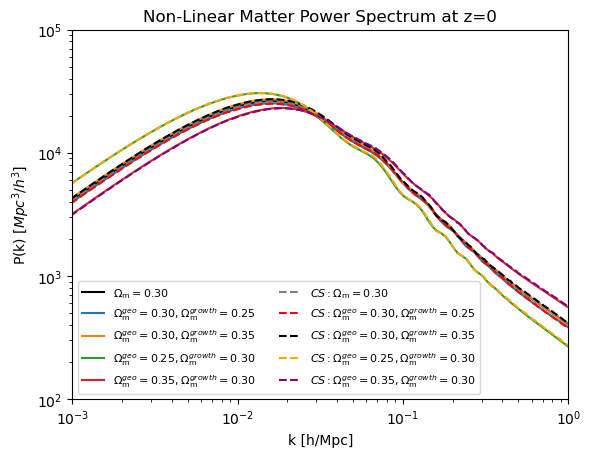

<Figure size 640x480 with 0 Axes>

In [ ]:
# This can import the CosmoSIS pickles for the validation

# with open("mps_k_h_069.pkl", "rb") as in_pkl:
#     k_h = pickle.load(in_pkl)
# with open("mps_om-geo-03-om-growth-03.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_03 = pickle.load(in_pkl)
# with open("mps_om-geo-03-om-growth-025.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_025 = pickle.load(in_pkl)
# with open("mps_om-geo-03-om-growth-035.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_035 = pickle.load(in_pkl)
# with open("mps_om-geo-025-om-growth-03.pkl", "rb") as in_pkl:
#     mps_geo_025_gr_03 = pickle.load(in_pkl)
# with open("mps_om-geo-035-om-growth-03.pkl", "rb") as in_pkl:
#     mps_geo_035_gr_03 = pickle.load(in_pkl)

plt.loglog(
    ks / h, nonlinear_pk_03_03[0, :] * h**3, color="black", label="$\\Omega_{\\rm m}=0.30$"
)
plt.loglog(
    ks / h,
    nonlinear_pk_03_025[0, :] * h**3,
    label="$\\Omega^{geo}_{\\rm m}=0.30, \\Omega^{growth}_{\\rm m}=0.25$",
)
plt.loglog(
    ks / h,
    nonlinear_pk_03_035[0, :] * h**3,
    label="$\\Omega^{geo}_{\\rm m}=0.30, \\Omega^{growth}_{\\rm m}=0.35$",
)
plt.loglog(
    ks / h,
    nonlinear_pk_025_03[0, :] * h**3,
    label="$\\Omega^{geo}_{\\rm m}=0.25,\\Omega^{growth}_{\\rm m}=0.30$",
)
plt.loglog(
    ks / h,
    nonlinear_pk_035_03[0, :] * h**3,
    label="$\\Omega^{geo}_{\\rm m}=0.35,\\Omega^{growth}_{\\rm m}=0.30$",
)

# plt.plot(
#     k_h,
#     mps_geo_03_gr_03[0, :],
#     label="$CS:\\Omega_{\\rm m}=0.30$",
#     color="grey",
#     linestyle="--",
# )
# plt.plot(
#     k_h,
#     mps_geo_03_gr_025[0, :],
#     label="$CS:\\Omega^{geo}_{\\rm m}=0.30,\\Omega^{growth}_{\\rm m}=0.25$",
#     color="red",
#     linestyle="--",
# )
# plt.plot(
#     k_h,
#     mps_geo_03_gr_035[0, :],
#     label="$CS:\\Omega^{geo}_{\\rm m}=0.30,\\Omega^{growth}_{\\rm m}=0.35$",
#     color="black",
#     linestyle="--",
# )
# plt.plot(
#     k_h,
#     mps_geo_025_gr_03[0, :],
#     label="$CS:\\Omega^{geo}_{\\rm m}=0.25,\\Omega^{growth}_{\\rm m}=0.30$",
#     color="orange",
#     linestyle="--",
# )
# plt.plot(
#     k_h,
#     mps_geo_035_gr_03[0, :],
#     label="$CS:\\Omega^{geo}_{\\rm m}=0.35,\\Omega^{growth}_{\\rm m}=0.30$",
#     color="purple",
#     linestyle="--",
# )

plt.xlabel("k [h/Mpc]")
plt.ylabel(r"P(k) [$Mpc^3/h^3$]")
plt.xlim(1e-3, 1e0)
plt.ylim(1e2, 1e5)
plt.title("Non-Linear Matter Power Spectrum at z=0")
plt.legend(ncol=2, fontsize=8)
plt.savefig("nl_power_spectra.png", dpi=300)
plt.show()
plt.clf()

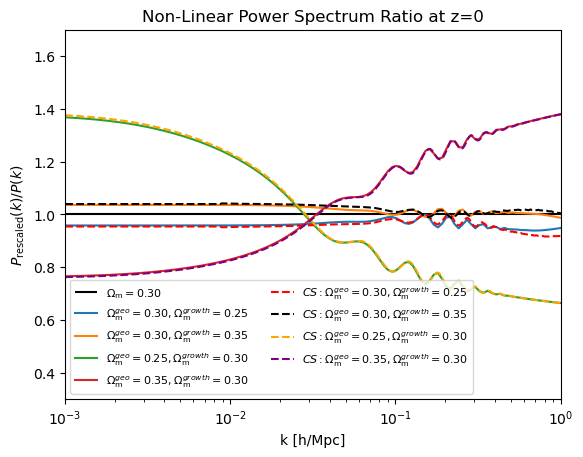

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot the ratio of the rescaled and the standard MPS

plt.hlines(1, np.min(ks), np.max(ks), label="$\\Omega_{\\rm m}=0.30$", color="black")
plt.plot(
    ks / h,
    nonlinear_pk_03_025[0, :] / nonlinear_pk_03_03[0, :],
    label="$\\Omega^{geo}_{\\rm m}=0.30, \\Omega^{growth}_{\\rm m}=0.25$",
)
plt.plot(
    ks / h,
    nonlinear_pk_03_035[0, :] / nonlinear_pk_03_03[0, :],
    label="$\\Omega^{geo}_{\\rm m}=0.30, \\Omega^{growth}_{\\rm m}=0.35$",
)
plt.plot(
    ks / h,
    nonlinear_pk_025_03[0, :] / nonlinear_pk_03_03[0, :],
    label="$\\Omega^{geo}_{\\rm m}=0.25, \\Omega^{growth}_{\\rm m}=0.30$",
)
plt.plot(
    ks / h,
    nonlinear_pk_035_03[0, :] / nonlinear_pk_03_03[0, :],
    label="$\\Omega^{geo}_{\\rm m}=0.35, \\Omega^{growth}_{\\rm m}=0.30$",
)

# plt.plot(
#     k_h,
#     mps_geo_03_gr_025[0, :] / mps_geo_03_gr_03[0, :],
#     label="$CS:\\Omega^{geo}_{\\rm m}=0.30, \\Omega^{growth}_{\\rm m}=0.25$",
#     color="red",
#     linestyle="--",
# )
# plt.plot(
#     k_h,
#     mps_geo_03_gr_035[0, :] / mps_geo_03_gr_03[0, :],
#     label="$CS:\\Omega^{geo}_{\\rm m}=0.30, \\Omega^{growth}_{\\rm m}=0.35$",
#     color="black",
#     linestyle="--",
# )
# plt.plot(
#     k_h,
#     mps_geo_025_gr_03[0, :] / mps_geo_03_gr_03[0, :],
#     label="$CS:\\Omega^{geo}_{\\rm m}=0.25, \\Omega^{growth}_{\\rm m}=0.30$",
#     color="orange",
#     linestyle="--",
# )
# plt.plot(
#     k_h,
#     mps_geo_035_gr_03[0, :] / mps_geo_03_gr_03[0, :],
#     label="$CS:\\Omega^{geo}_{\\rm m}=0.35, \\Omega^{growth}_{\\rm m}=0.30$",
#     color="purple",
#     linestyle="--",
# )

plt.title("Non-Linear Power Spectrum Ratio at z=0")
plt.xlabel("k [h/Mpc]")
plt.ylabel("$P_{\\rm rescaled}(k)/P(k)$")
plt.xscale("log")
plt.xlim(1e-3, 1e0)
plt.ylim(0.3, 1.7)
plt.legend(ncol=2, fontsize=8)
plt.savefig("nl_power_spectra_ratio.png", dpi=300)
plt.show()
plt.clf()